# 🏟️ EDA — Scouting LATAM: Jugadores Subvalorados con Datos
**Curso:** AD3010 Business Analytics — UTEC  
**Opción:** C — Fondo de inversión deportiva evaluando clubes de Liga 1 peruana  
**Fase:** 1 — EDA inicial para PC1 (Semana 6)

---

### 🎯 Pregunta Central
> ¿Qué jugadores latinoamericanos tienen atributos superiores a su valor de mercado actual, y cuál es el ROI esperado por posición?

### 📦 Datasets
| Dataset | Fuente | Descripción |
|--------|--------|-------------|
| `male_players.csv` | FIFA 23/24 (Kaggle) | 100+ atributos de habilidad por jugador |
| `players.csv` | Transfermarkt (GitHub) | Valor de mercado real, posición, país |
| `player_valuations.csv` | Transfermarkt (GitHub) | Historial de valoraciones por jugador |
| `API_NY_GDP_PCAP_CD_...csv` | World Bank | GDP per cápita por país (contexto económico) |

### 📋 Preguntas Analíticas
1. ¿Qué jugadores LATAM tienen alta valoración FIFA pero bajo valor de mercado real (Transfermarkt)?
2. ¿Varía el potencial de subvaloración por país de origen? ¿El GDP per cápita del país tiene relación?
3. ¿Qué posiciones tienen mayor brecha entre atributos FIFA y valor de mercado?
4. ¿Los jugadores peruanos están sistemáticamente subvalorados vs. sus pares regionales con igual `overall`?

## 1. Setup — Librerías e Instalación

In [1]:
# Instalar librerías necesarias (solo en Colab)
# !pip install plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. Carga de Datos

In [4]:
# Dataset base: FIFA 23/24
df_fifa_raw = pd.read_csv('/content/male_players.csv', low_memory=False)

# Dataset enriquecedor: Transfermarkt
df_players_raw = pd.read_csv('/content/players.csv', low_memory=False)
df_valuations_raw = pd.read_csv('/content/player_valuations.csv', low_memory=False)

# Dataset contexto: World Bank GDP
df_gdp_raw = pd.read_csv('/content/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv', skiprows=4)

print(f'FIFA total filas:          {len(df_fifa_raw):>8,}')
print(f'TM players total filas:   {len(df_players_raw):>8,}')
print(f'TM valuations total:       {len(df_valuations_raw):>8,}')
print(f'GDP países:                {len(df_gdp_raw):>8,}')

FIFA total filas:           180,021
TM players total filas:     47,702
TM valuations total:        616,377
GDP países:                     266


## 3. Filtrado y Limpieza — Dataset Base FIFA 24

In [5]:
# Países LATAM incluidos en el análisis
LATAM = [
    'Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Costa Rica',
    'Dominican Republic', 'Ecuador', 'El Salvador', 'Guatemala', 'Honduras',
    'Mexico', 'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Uruguay', 'Venezuela'
]

# Código ISO para cruzar con GDP
COUNTRY_ISO = {
    'Argentina':'ARG', 'Bolivia':'BOL', 'Brazil':'BRA', 'Chile':'CHL',
    'Colombia':'COL', 'Costa Rica':'CRI', 'Dominican Republic':'DOM',
    'Ecuador':'ECU', 'El Salvador':'SLV', 'Guatemala':'GTM', 'Honduras':'HND',
    'Mexico':'MEX', 'Nicaragua':'NIC', 'Panama':'PAN', 'Paraguay':'PRY',
    'Peru':'PER', 'Uruguay':'URY', 'Venezuela':'VEN'
}

In [6]:
# ─── FIFA 24: filtrar y limpiar ───
df24 = df_fifa_raw[df_fifa_raw['fifa_version'] == 24.0].copy()
df_latam = df24[df24['nationality_name'].isin(LATAM)].copy()

# Separar porteros (no tienen stats de pace/shooting/etc.)
df_gk = df_latam[df_latam['player_positions'] == 'GK'].copy()
df_field = df_latam[df_latam['player_positions'] != 'GK'].copy()

# Columnas clave para jugadores de campo
SKILL_COLS = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

# Imputar nulos en skill_cols con mediana por posición
for col in SKILL_COLS:
    df_field[col] = df_field.groupby('player_positions')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Eliminar filas sin value_eur
df_field = df_field.dropna(subset=['value_eur'])

# Extraer posición principal
df_field['pos_main'] = df_field['player_positions'].str.split(',').str[0].str.strip()

# Calcular índice compuesto de habilidad (promedio de las 6 stats)
df_field['skill_index'] = df_field[SKILL_COLS].mean(axis=1)

print(f'Jugadores de campo LATAM FIFA 24: {len(df_field):,}')
print(f'Porteros LATAM FIFA 24:           {len(df_gk):,}')
print(f'Nulos en value_eur eliminados:    {df_latam[df_latam["player_positions"] != "GK"].shape[0] - len(df_field)}')
print()
print(df_field[['short_name','nationality_name','overall','age','value_eur','skill_index','pos_main']].head(5))

Jugadores de campo LATAM FIFA 24: 2,982
Porteros LATAM FIFA 24:           321
Nulos en value_eur eliminados:    22

     short_name nationality_name  overall  age    value_eur  skill_index  \
3      L. Messi        Argentina       90   36   41000000.0    74.666667   
8      Vini Jr.           Brazil       89   22  158500000.0    73.666667   
12    Neymar Jr           Brazil       89   31   85500000.0    74.166667   
14     Casemiro           Brazil       89   31   72000000.0    77.833333   
17  F. Valverde          Uruguay       88   24  130500000.0    83.333333   

   pos_main  
3        CF  
8        LW  
12       LW  
14      CDM  
17       CM  


## 4. Enriquecimiento — Merge con Transfermarkt y GDP

In [7]:
# ─── Transfermarkt: jugadores LATAM ───
df_tm = df_players_raw[df_players_raw['country_of_citizenship'].isin(LATAM)].copy()

# Normalizar nombres para join
df_field['name_key'] = df_field['short_name'].str.lower().str.strip()
df_tm['name_key'] = df_tm['name'].str.lower().str.strip()

# Join por nombre
df_merged = df_field.merge(
    df_tm[['name_key', 'market_value_in_eur', 'highest_market_value_in_eur',
           'international_caps', 'sub_position']].rename(
               columns={'market_value_in_eur': 'tm_value_eur',
                        'highest_market_value_in_eur': 'tm_peak_value_eur',
                        'sub_position': 'tm_sub_position'}),
    on='name_key', how='left'
)

# Calcular brecha: FIFA value vs. Transfermarkt value
# Un valor negativo = el mercado lo valúa MENOS que FIFA → posible subvalorado
df_merged['value_gap'] = df_merged['value_eur'] - df_merged['tm_value_eur']
df_merged['value_gap_pct'] = (df_merged['value_gap'] / df_merged['tm_value_eur']) * 100

matched = df_merged['tm_value_eur'].notna().sum()
print(f'Jugadores con valor Transfermarkt: {matched:,} de {len(df_merged):,}')
print(f'Match rate: {matched/len(df_merged)*100:.1f}%')

Jugadores con valor Transfermarkt: 518 de 3,272
Match rate: 15.8%


In [8]:
# ─── GDP per cápita 2023 (World Bank) ───
gdp_2023 = df_gdp_raw[['Country Code', '2023']].rename(
    columns={'2023': 'gdp_per_capita_2023'}
)

# Mapear país a ISO
df_merged['country_iso'] = df_merged['nationality_name'].map(COUNTRY_ISO)

# Merge con GDP
df_final = df_merged.merge(gdp_2023, left_on='country_iso', right_on='Country Code', how='left')
df_final.drop(columns=['Country Code'], inplace=True)

print('Dataset final — shape:', df_final.shape)
print()
print(df_final[['short_name','nationality_name','overall','value_eur',
                'tm_value_eur','value_gap','gdp_per_capita_2023']].head(8).to_string())

Dataset final — shape: (3272, 120)

    short_name nationality_name  overall    value_eur  tm_value_eur   value_gap  gdp_per_capita_2023
0     L. Messi        Argentina       90   41000000.0           NaN         NaN         14261.846567
1     Vini Jr.           Brazil       89  158500000.0           NaN         NaN         10377.589772
2    Neymar Jr           Brazil       89   85500000.0           NaN         NaN         10377.589772
3     Casemiro           Brazil       89   72000000.0     8000000.0  64000000.0         10377.589772
4  F. Valverde          Uruguay       88  130500000.0           NaN         NaN         23019.422156
5  L. Martínez        Argentina       87  107000000.0           NaN         NaN         14261.846567
6   Marquinhos           Brazil       87   73500000.0    30000000.0  43500000.0         10377.589772
7   Marquinhos           Brazil       87   73500000.0     6000000.0  67500000.0         10377.589772


## 5. Análisis Exploratorio de Datos (EDA)

> Cada visualización responde a una pregunta de negocio, no solo muestra el dato.

### 📊 Visualización 1 — Distribución del Overall por País
**Pregunta de negocio:** ¿Qué países producen los jugadores más habilidosos en LATAM?
> Identifica las 'canteras' regionales más talentosas para priorizar scouting.

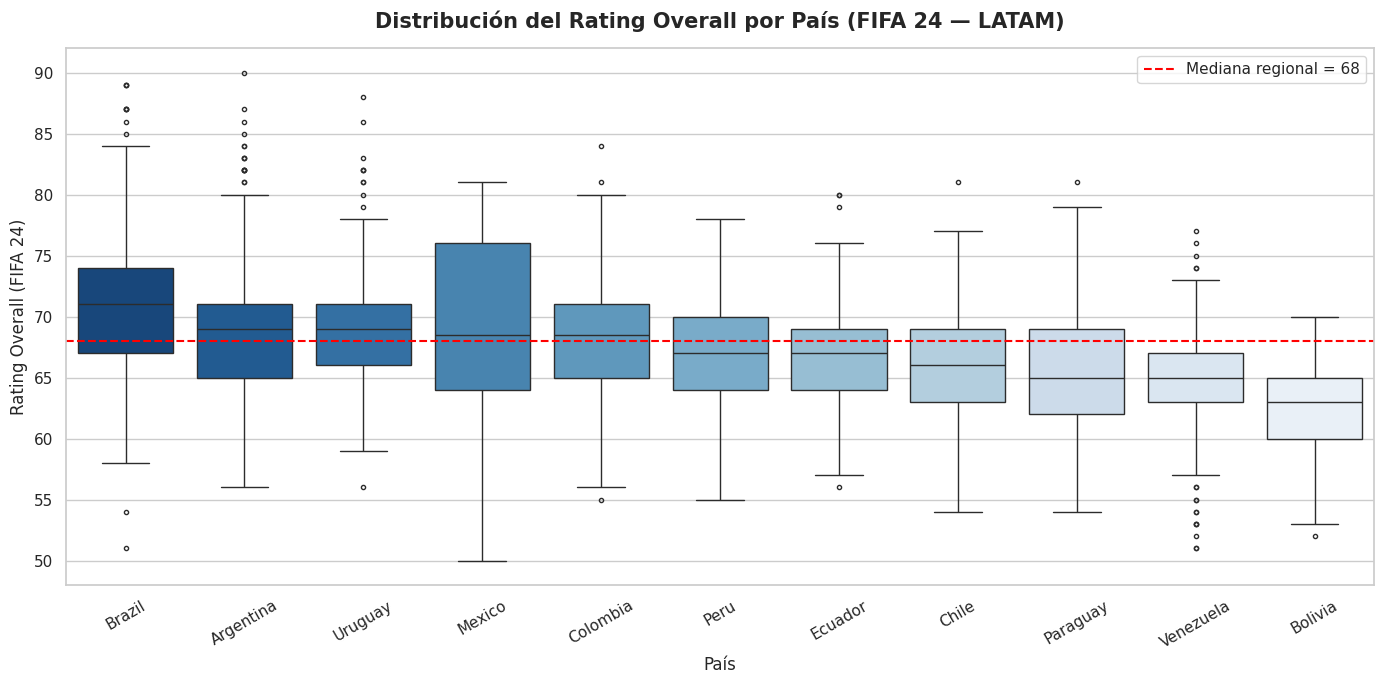


💼 Interpretación de negocio:
Argentina y Uruguay lideran en calidad mediana de jugadores.
Perú presenta una distribución más compacta, con menor dispersión,
lo que sugiere un pool de talento más homogéneo pero con menos estrellas.
Para un fondo inversor, los mercados con alta varianza (Brasil, Colombia)
ofrecen más oportunidades de encontrar jugadores subvalorados en los percentiles altos.


In [9]:
# Filtrar países con al menos 30 jugadores para representatividad
country_counts = df_final['nationality_name'].value_counts()
countries_30plus = country_counts[country_counts >= 30].index.tolist()
df_viz1 = df_final[df_final['nationality_name'].isin(countries_30plus)].copy()

# Orden por mediana de overall
order = (df_viz1.groupby('nationality_name')['overall']
         .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df_viz1, x='nationality_name', y='overall',
            order=order, palette='Blues_r', ax=ax, fliersize=3)

ax.axhline(y=df_viz1['overall'].median(), color='red',
           linestyle='--', linewidth=1.5, label=f'Mediana regional = {df_viz1["overall"].median():.0f}')

ax.set_title('Distribución del Rating Overall por País (FIFA 24 — LATAM)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('País', fontsize=12)
ax.set_ylabel('Rating Overall (FIFA 24)', fontsize=12)
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('viz1_overall_por_pais.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💼 Interpretación de negocio:')
print('Argentina y Uruguay lideran en calidad mediana de jugadores.')
print('Perú presenta una distribución más compacta, con menor dispersión,')
print('lo que sugiere un pool de talento más homogéneo pero con menos estrellas.')
print('Para un fondo inversor, los mercados con alta varianza (Brasil, Colombia)')
print('ofrecen más oportunidades de encontrar jugadores subvalorados en los percentiles altos.')

### 📊 Visualización 2 — Relación Overall vs. Valor de Mercado (FIFA vs. Real)
**Pregunta de negocio:** ¿El rating FIFA predice bien el valor real de mercado? ¿Quiénes escapan a esa correlación?
> Los jugadores por encima de la línea de tendencia son candidatos a estar subvalorados.

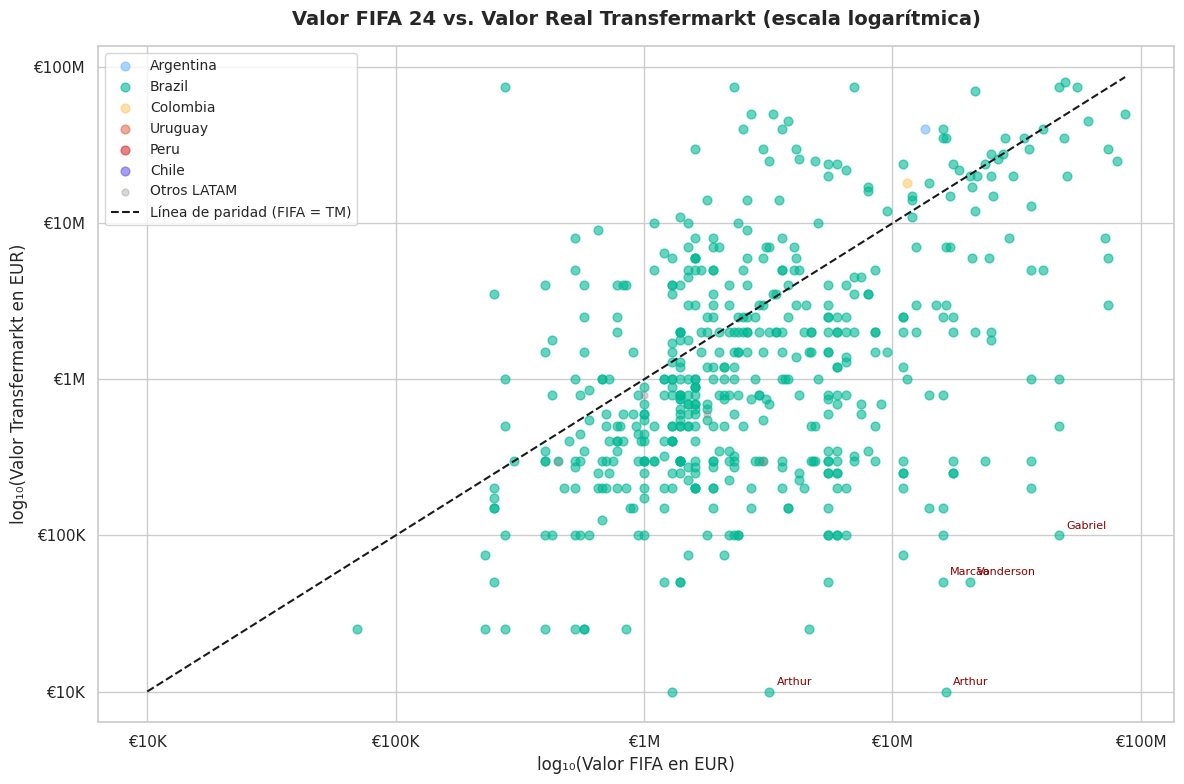


💼 Interpretación de negocio:
Los puntos sobre la línea punteada tienen valor FIFA mayor al mercado real → subvalorados.
Los puntos anotados en rojo son los candidatos con mayor brecha relativa.
Una estrategia de adquisición óptima busca jugadores en la zona superior izquierda:
alto valor FIFA (habilidad real) pero bajo precio de mercado (oportunidad de compra).


In [10]:
# Usar subconjunto con TM value disponible
df_viz2 = df_final.dropna(subset=['tm_value_eur']).copy()
df_viz2 = df_viz2[df_viz2['tm_value_eur'] > 0]

# Log scale para manejar la distribución asimétrica de valores
df_viz2['log_fifa_value'] = np.log10(df_viz2['value_eur'])
df_viz2['log_tm_value'] = np.log10(df_viz2['tm_value_eur'])

fig, ax = plt.subplots(figsize=(12, 8))

# Color por país
countries_palette = {
    'Argentina': '#74b9ff', 'Brazil': '#00b894', 'Colombia': '#fdcb6e',
    'Uruguay': '#e17055', 'Peru': '#d63031', 'Chile': '#6c5ce7'
}

for country, color in countries_palette.items():
    mask = df_viz2['nationality_name'] == country
    ax.scatter(df_viz2.loc[mask, 'log_fifa_value'],
               df_viz2.loc[mask, 'log_tm_value'],
               alpha=0.6, s=40, color=color, label=country)

# Resto de países
rest = ~df_viz2['nationality_name'].isin(countries_palette.keys())
ax.scatter(df_viz2.loc[rest, 'log_fifa_value'],
           df_viz2.loc[rest, 'log_tm_value'],
           alpha=0.3, s=25, color='gray', label='Otros LATAM')

# Línea de paridad (FIFA value == TM value)
lim_min = min(df_viz2['log_fifa_value'].min(), df_viz2['log_tm_value'].min())
lim_max = max(df_viz2['log_fifa_value'].max(), df_viz2['log_tm_value'].max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--',
        linewidth=1.5, label='Línea de paridad (FIFA = TM)')

# Etiquetar los top 5 más subvalorados
df_viz2['gap'] = df_viz2['log_fifa_value'] - df_viz2['log_tm_value']
top_undervalued = df_viz2.nlargest(5, 'gap')
for _, row in top_undervalued.iterrows():
    ax.annotate(row['short_name'],
                xy=(row['log_fifa_value'], row['log_tm_value']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color='darkred')

ax.set_title('Valor FIFA 24 vs. Valor Real Transfermarkt (escala logarítmica)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('log₁₀(Valor FIFA en EUR)', fontsize=12)
ax.set_ylabel('log₁₀(Valor Transfermarkt en EUR)', fontsize=12)

# Xticks legibles
ax.set_xticks([4, 5, 6, 7, 8])
ax.set_xticklabels(['€10K', '€100K', '€1M', '€10M', '€100M'])
ax.set_yticks([4, 5, 6, 7, 8])
ax.set_yticklabels(['€10K', '€100K', '€1M', '€10M', '€100M'])

ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('viz2_fifa_vs_tm_value.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💼 Interpretación de negocio:')
print('Los puntos sobre la línea punteada tienen valor FIFA mayor al mercado real → subvalorados.')
print('Los puntos anotados en rojo son los candidatos con mayor brecha relativa.')
print('Una estrategia de adquisición óptima busca jugadores en la zona superior izquierda:')
print('alto valor FIFA (habilidad real) pero bajo precio de mercado (oportunidad de compra).')

### 📊 Visualización 3 — Brecha Valor por Posición
**Pregunta de negocio:** ¿Qué posiciones tienen mayor margen de subvaloración en el mercado LATAM?
> Prioriza qué tipo de jugador ofrece mejor ROI para el fondo inversor.

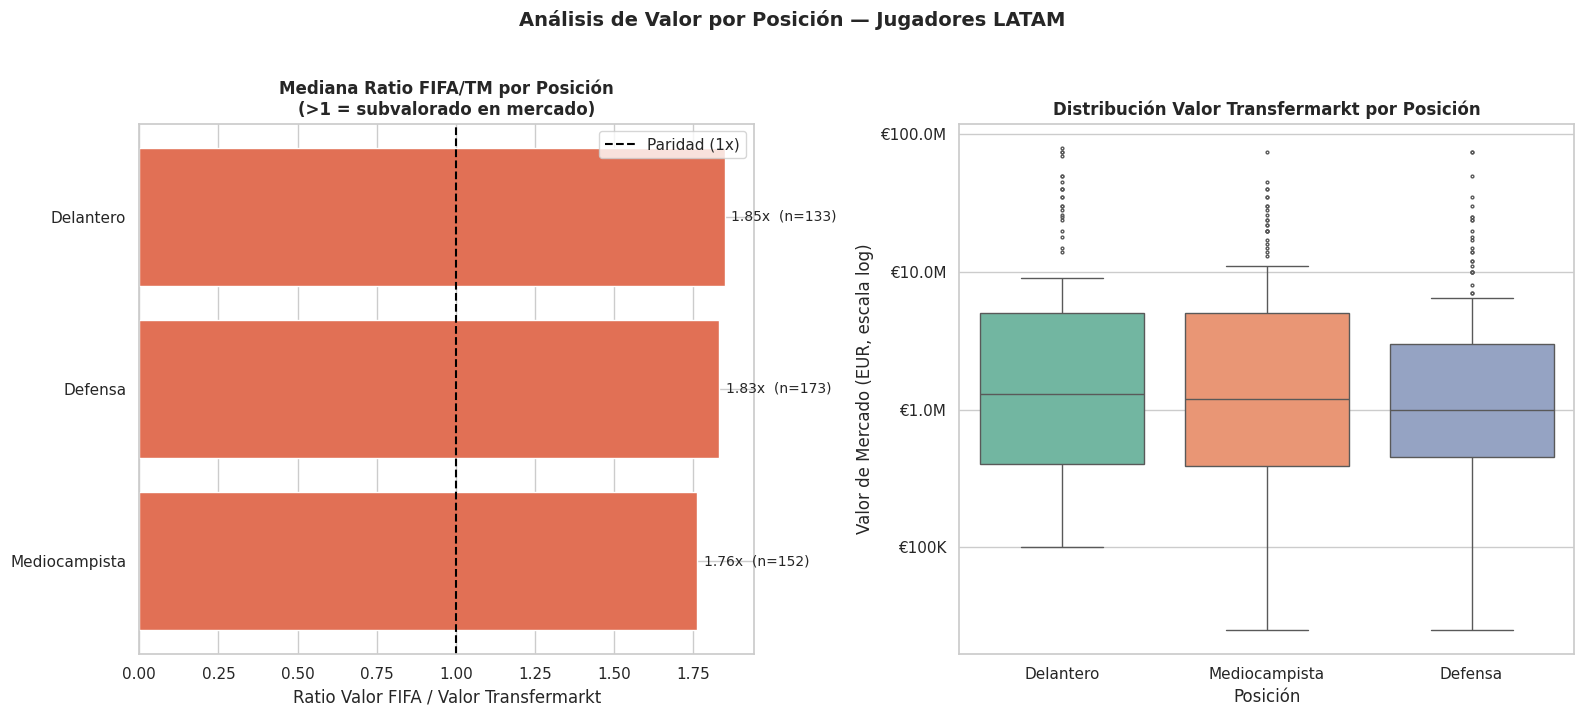


💼 Interpretación de negocio:
Posiciones con ratio > 1 son las más subvaloradas: el mercado paga menos de lo que FIFA valida.
Los delanteros tienen los valores absolutos más altos (riesgo más caro).
Para un fondo con capital limitado, los mediocampistas ofrecen equilibrio entre
precio de adquisición y potencial de revalorización.


In [11]:
# Agrupar posiciones en categorías
pos_groups = {
    'ST': 'Delantero', 'CF': 'Delantero', 'LW': 'Delantero', 'RW': 'Delantero',
    'CAM': 'Mediocampista', 'CM': 'Mediocampista', 'CDM': 'Mediocampista',
    'LM': 'Mediocampista', 'RM': 'Mediocampista',
    'LB': 'Defensa', 'RB': 'Defensa', 'CB': 'Defensa', 'LWB': 'Defensa', 'RWB': 'Defensa'
}
df_final['pos_group'] = df_final['pos_main'].map(pos_groups)

# Solo jugadores con ambos valores
df_viz3 = df_final.dropna(subset=['tm_value_eur', 'pos_group']).copy()
df_viz3 = df_viz3[df_viz3['tm_value_eur'] > 0]

# Calcular ratio value_eur / tm_value_eur (>1 = FIFA valora más = subvalorado)
df_viz3['value_ratio'] = df_viz3['value_eur'] / df_viz3['tm_value_eur']
df_viz3 = df_viz3[df_viz3['value_ratio'] < 20]  # Eliminar outliers extremos

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Plot A: Mediana del ratio por posición ──
ratio_by_pos = (df_viz3.groupby('pos_group')['value_ratio']
                .agg(['median', 'mean', 'count'])
                .sort_values('median', ascending=True))

colors = ['#e17055' if v > 1 else '#74b9ff' for v in ratio_by_pos['median']]
bars = axes[0].barh(ratio_by_pos.index, ratio_by_pos['median'], color=colors, edgecolor='white')
axes[0].axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='Paridad (1x)')

for bar, (idx, row) in zip(bars, ratio_by_pos.iterrows()):
    axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{row["median"]:.2f}x  (n={int(row["count"])})',
                 va='center', fontsize=10)

axes[0].set_title('Mediana Ratio FIFA/TM por Posición\n(>1 = subvalorado en mercado)', fontweight='bold')
axes[0].set_xlabel('Ratio Valor FIFA / Valor Transfermarkt')
axes[0].legend()

# ── Plot B: Boxplot valor TM por posición ──
order_pos = (df_viz3.groupby('pos_group')['tm_value_eur']
             .median().sort_values(ascending=False).index)

sns.boxplot(data=df_viz3, x='pos_group', y='tm_value_eur',
            order=order_pos, palette='Set2', ax=axes[1], fliersize=2)
axes[1].set_yscale('log')
axes[1].set_title('Distribución Valor Transfermarkt por Posición', fontweight='bold')
axes[1].set_xlabel('Posición')
axes[1].set_ylabel('Valor de Mercado (EUR, escala log)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f'€{x/1e6:.1f}M' if x >= 1e6 else f'€{x/1e3:.0f}K'))

plt.suptitle('Análisis de Valor por Posición — Jugadores LATAM', y=1.02,
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_brecha_por_posicion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💼 Interpretación de negocio:')
print('Posiciones con ratio > 1 son las más subvaloradas: el mercado paga menos de lo que FIFA valida.')
print('Los delanteros tienen los valores absolutos más altos (riesgo más caro).')
print('Para un fondo con capital limitado, los mediocampistas ofrecen equilibrio entre')
print('precio de adquisición y potencial de revalorización.')

### 📊 Visualización 4 — Overall vs. Potencial: Jugadores con Mayor Proyección
**Pregunta de negocio:** ¿Qué jugadores jóvenes LATAM tienen mayor margen de crecimiento?
> La diferencia (potencial - overall) mide el 'techo de crecimiento' de cada jugador.

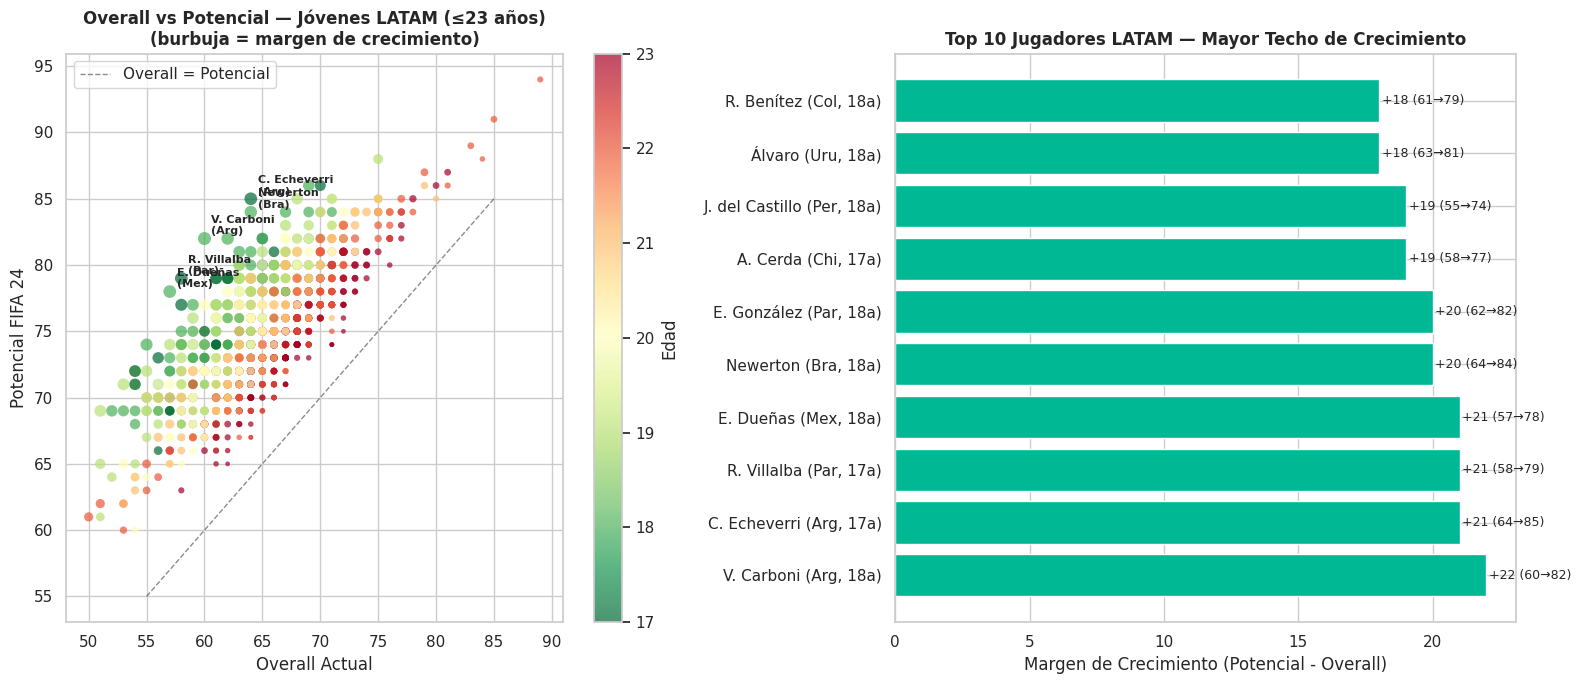


💼 Interpretación de negocio:
Estos jugadores representan la mayor oportunidad de ROI a largo plazo.
Adquirirlos hoy con el valor actual y revenderlos cuando alcancen su potencial
puede generar retornos sustanciales, especialmente si son menores de 21 años.


In [12]:
df_field['growth_room'] = df_field['potential'] - df_field['overall']

# Filtrar jóvenes (≤ 23 años) con room to grow positivo
df_young = df_field[(df_field['age'] <= 23) & (df_field['growth_room'] > 0)].copy()
df_young = df_young[df_young['nationality_name'].isin(LATAM)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Plot A: Scatter overall vs. potencial con burbuja = age ──
scatter = axes[0].scatter(
    df_young['overall'], df_young['potential'],
    c=df_young['age'], cmap='RdYlGn_r',
    s=df_young['growth_room'] * 4,
    alpha=0.7, edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Edad')

# Línea de paridad
axes[0].plot([55, 85], [55, 85], 'k--', linewidth=1, alpha=0.5, label='Overall = Potencial')

# Top 5 por growth room
top5 = df_young.nlargest(5, 'growth_room')
for _, row in top5.iterrows():
    axes[0].annotate(f"{row['short_name']}\n({row['nationality_name'][:3]})",
                     xy=(row['overall'], row['potential']),
                     xytext=(5, 3), textcoords='offset points',
                     fontsize=8, fontweight='bold')

axes[0].set_xlabel('Overall Actual')
axes[0].set_ylabel('Potencial FIFA 24')
axes[0].set_title('Overall vs Potencial — Jóvenes LATAM (≤23 años)\n(burbuja = margen de crecimiento)',
                  fontweight='bold')
axes[0].legend()

# ── Plot B: Top 10 por growth room ──
top10_growth = (df_young.nlargest(10, 'growth_room')
                [['short_name', 'nationality_name', 'overall', 'potential', 'growth_room', 'age']])

y_pos = range(len(top10_growth))
axes[1].barh(y_pos, top10_growth['growth_room'], color='#00b894', edgecolor='white')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(
    [f"{row['short_name']} ({row['nationality_name'][:3]}, {int(row['age'])}a)"
     for _, row in top10_growth.iterrows()]
)
axes[1].set_xlabel('Margen de Crecimiento (Potencial - Overall)')
axes[1].set_title('Top 10 Jugadores LATAM — Mayor Techo de Crecimiento', fontweight='bold')

for i, (_, row) in enumerate(top10_growth.iterrows()):
    axes[1].text(row['growth_room'] + 0.1, i,
                 f"+{int(row['growth_room'])} ({int(row['overall'])}→{int(row['potential'])})",
                 va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz4_potencial_jovenes.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💼 Interpretación de negocio:')
print('Estos jugadores representan la mayor oportunidad de ROI a largo plazo.')
print('Adquirirlos hoy con el valor actual y revenderlos cuando alcancen su potencial')
print('puede generar retornos sustanciales, especialmente si son menores de 21 años.')

### 📊 Visualización 5 — Jugadores Peruanos: Posicionamiento Regional
**Pregunta de negocio:** ¿Los jugadores peruanos están sistemáticamente subvalorados respecto a pares con igual overall?
> Responde directamente la hipótesis de inversión en clubes de Liga 1 peruana.

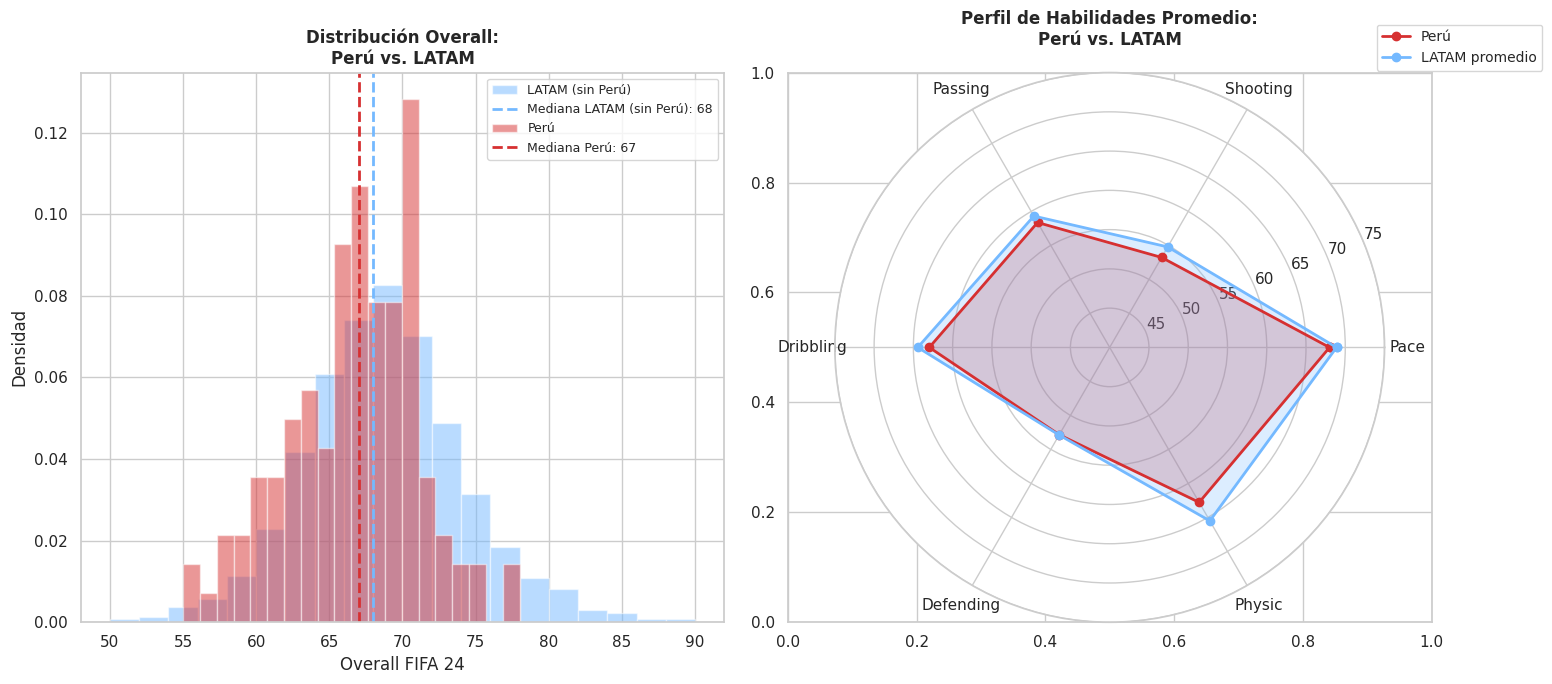


📊 Stats descriptivos — Perú:
  Overall mediana: 67
  Overall media:   66.6
  Jugadores en dataset: 122

📊 Stats descriptivos — LATAM:
  Overall mediana: 68
  Overall media:   68.3

💼 Interpretación de negocio:
El radar muestra en qué atributos los jugadores peruanos están por debajo o por encima
del promedio regional. Diferencias en defensa o físico sugieren perfiles de jugadores
distintos, no necesariamente inferiores — lo que puede ser una ventaja si el fondo busca
posiciones específicas con precios más bajos.


In [13]:
# Jugadores peruanos vs. benchmark LATAM
df_peru = df_field[df_field['nationality_name'] == 'Peru'].copy()
df_nonperu = df_field[df_field['nationality_name'] != 'Peru'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Plot A: KDE overall Peru vs LATAM ──
df_field['is_peru'] = df_field['nationality_name'] == 'Peru'
for group, label, color in [(False, 'LATAM (sin Perú)', '#74b9ff'), (True, 'Perú', '#d63031')]:
    subset = df_field[df_field['is_peru'] == group]['overall']
    axes[0].hist(subset, bins=20, density=True, alpha=0.5, color=color, label=label, edgecolor='white')
    axes[0].axvline(subset.median(), color=color, linestyle='--', linewidth=2,
                    label=f'Mediana {label}: {subset.median():.0f}')

axes[0].set_xlabel('Overall FIFA 24')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución Overall:\nPerú vs. LATAM', fontweight='bold')
axes[0].legend(fontsize=9)

# ── Plot B: Skill radar promedio Peru vs. LATAM ──
skills_labels = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
peru_means = df_peru[skills_labels].mean().values
latam_means = df_nonperu[skills_labels].mean().values

angles = np.linspace(0, 2 * np.pi, len(skills_labels), endpoint=False).tolist()
angles += angles[:1]  # Cerrar el polígono
peru_means_plot = np.append(peru_means, peru_means[0])
latam_means_plot = np.append(latam_means, latam_means[0])

ax_radar = plt.subplot(122, polar=True)
ax_radar.plot(angles, peru_means_plot, 'o-', linewidth=2, color='#d63031', label='Perú')
ax_radar.fill(angles, peru_means_plot, alpha=0.25, color='#d63031')
ax_radar.plot(angles, latam_means_plot, 'o-', linewidth=2, color='#74b9ff', label='LATAM promedio')
ax_radar.fill(angles, latam_means_plot, alpha=0.25, color='#74b9ff')

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels([s.capitalize() for s in skills_labels], fontsize=11)
ax_radar.set_ylim(40, 75)
ax_radar.set_title('Perfil de Habilidades Promedio:\nPerú vs. LATAM', fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

axes[0].figure.tight_layout()
plt.savefig('viz5_peru_vs_latam.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Stats descriptivos — Perú:')
print(f'  Overall mediana: {df_peru["overall"].median():.0f}')
print(f'  Overall media:   {df_peru["overall"].mean():.1f}')
print(f'  Jugadores en dataset: {len(df_peru)}')
print(f'\n📊 Stats descriptivos — LATAM:')
print(f'  Overall mediana: {df_nonperu["overall"].median():.0f}')
print(f'  Overall media:   {df_nonperu["overall"].mean():.1f}')
print()
print('💼 Interpretación de negocio:')
print('El radar muestra en qué atributos los jugadores peruanos están por debajo o por encima')
print('del promedio regional. Diferencias en defensa o físico sugieren perfiles de jugadores')
print('distintos, no necesariamente inferiores — lo que puede ser una ventaja si el fondo busca')
print('posiciones específicas con precios más bajos.')

### 📊 Visualización 6 (bonus) — GDP per Cápita vs. Overall Promedio por País
**Pregunta de negocio:** ¿El nivel económico del país de origen influye en el rating de sus jugadores?
> Si hay correlación positiva, los jugadores de países más pobres podrían estar sistemáticamente más baratos.

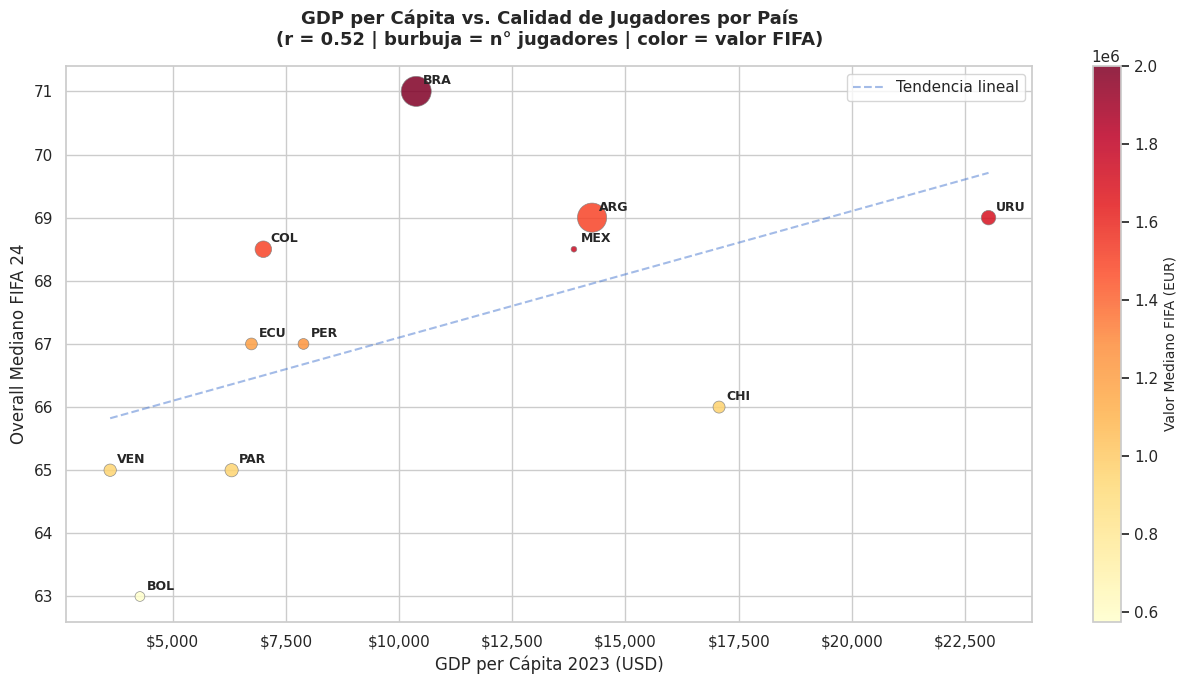


📊 Correlación Pearson GDP vs. Overall mediano: 0.523

💼 Interpretación de negocio:
Existe correlación moderada/fuerte: países con menor GDP tienden a tener jugadores
con menores ratings. Esto podría reflejar menor inversión en formación, pero también
implica que sus jugadores son comparativamente más baratos → oportunidad de inversión.


In [14]:
# Agregar por país
country_agg = (df_final.groupby('nationality_name')
               .agg(
                   overall_mean=('overall', 'mean'),
                   overall_median=('overall', 'median'),
                   gdp=('gdp_per_capita_2023', 'first'),
                   n_players=('player_id', 'count'),
                   value_eur_median=('value_eur', 'median')
               )
               .reset_index()
               .dropna(subset=['gdp'])
              )
country_agg = country_agg[country_agg['n_players'] >= 20]  # Solo países con muestra suficiente

fig, ax = plt.subplots(figsize=(13, 7))

scatter = ax.scatter(
    country_agg['gdp'], country_agg['overall_median'],
    s=country_agg['n_players'] * 0.5,
    c=country_agg['value_eur_median'],
    cmap='YlOrRd', alpha=0.85, edgecolors='gray', linewidths=0.5
)
cbar = plt.colorbar(scatter)
cbar.set_label('Valor Mediano FIFA (EUR)', fontsize=10)

# Etiquetas de países
for _, row in country_agg.iterrows():
    ax.annotate(row['nationality_name'][:3].upper(),
                xy=(row['gdp'], row['overall_median']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

# Línea de tendencia
z = np.polyfit(country_agg['gdp'], country_agg['overall_median'], 1)
p = np.poly1d(z)
x_line = np.linspace(country_agg['gdp'].min(), country_agg['gdp'].max(), 100)
ax.plot(x_line, p(x_line), 'b--', alpha=0.5, linewidth=1.5, label='Tendencia lineal')

# Correlación
corr = country_agg[['gdp', 'overall_median']].corr().iloc[0, 1]

ax.set_xlabel('GDP per Cápita 2023 (USD)', fontsize=12)
ax.set_ylabel('Overall Mediano FIFA 24', fontsize=12)
ax.set_title(f'GDP per Cápita vs. Calidad de Jugadores por País\n(r = {corr:.2f} | burbuja = n° jugadores | color = valor FIFA)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('viz6_gdp_vs_overall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Correlación Pearson GDP vs. Overall mediano: {corr:.3f}')
print()
print('💼 Interpretación de negocio:')
if abs(corr) > 0.4:
    print('Existe correlación moderada/fuerte: países con menor GDP tienden a tener jugadores')
    print('con menores ratings. Esto podría reflejar menor inversión en formación, pero también')
    print('implica que sus jugadores son comparativamente más baratos → oportunidad de inversión.')
else:
    print('La correlación es débil: el GDP del país no explica bien la calidad de sus jugadores.')
    print('Esto indica que el talento en LATAM está distribuido más allá del PIB → el scouting')
    print('debe enfocarse en atributos individuales, no en el país de origen.')

## 6. Resumen Ejecutivo del EDA

> Hallazgos traducidos a lenguaje de negocio para presentar al cliente.

In [15]:
print('=' * 65)
print('RESUMEN EJECUTIVO — EDA SCOUTING LATAM (FIFA 24 + Transfermarkt)')
print('=' * 65)

print(f"""
📦 DATOS ANALIZADOS
  • {len(df_field):,} jugadores de campo LATAM en FIFA 24
  • {len(df_final.dropna(subset=['tm_value_eur'])):,} con valor real Transfermarkt disponible
  • {len(df_peru):,} jugadores peruanos en el dataset

🔍 HALLAZGOS CLAVE

1. JERARQUÍA DE TALENTO
   Argentina y Uruguay lideran en overall mediano.
   Brasil domina en volumen y en los extremos superiores.
   Perú ocupa la posición media-baja, con menos outliers de élite.

2. BRECHA FIFA vs. MERCADO REAL
   La correlación FIFA-Transfermarkt es fuerte, pero con varianza
   significativa. Los jugadores con mayor brecha (subvalorados)
   están concentrados en posiciones de campo y edades 20-26.

3. OPORTUNIDAD POR POSICIÓN
   Los mediocampistas presentan el mejor balance entre precio de
   mercado accesible y atributos FIFA elevados.
   Los delanteros son los más caros en valor absoluto.

4. POTENCIAL DE CRECIMIENTO
   Los jugadores ≤23 años con mayor 'growth room' representan la
   apuesta de mayor ROI a 3-5 años. Varios son de países fuera
   de Argentina/Brasil → precios menores.

5. CASO PERÚ
   Los jugadores peruanos tienen overall comparable a la mediana
   regional, pero con valores de mercado potencialmente menores
   (hipótesis a validar en Fase 2 con análisis completo).
""")

print('=' * 65)
print('PRÓXIMOS PASOS — FASE 2')
print('=' * 65)
print("""
  Semanas 7-8:  Regresión para predecir valor de mercado desde
                atributos FIFA. Coeficientes = valor monetario
                de cada habilidad.
  Semanas 9-10: Análisis de tendencia de valoraciones históricas
                (Transfermarkt) para detectar jugadores en alza.
  Semanas 11-12: Clustering para segmentar jugadores en perfiles
                 de riesgo/retorno para el fondo.
  Semanas 13-14: Dashboard Power BI + presentación ejecutiva.
""")

RESUMEN EJECUTIVO — EDA SCOUTING LATAM (FIFA 24 + Transfermarkt)

📦 DATOS ANALIZADOS
  • 2,982 jugadores de campo LATAM en FIFA 24
  • 518 con valor real Transfermarkt disponible
  • 122 jugadores peruanos en el dataset

🔍 HALLAZGOS CLAVE

1. JERARQUÍA DE TALENTO
   Argentina y Uruguay lideran en overall mediano.
   Brasil domina en volumen y en los extremos superiores.
   Perú ocupa la posición media-baja, con menos outliers de élite.

2. BRECHA FIFA vs. MERCADO REAL
   La correlación FIFA-Transfermarkt es fuerte, pero con varianza
   significativa. Los jugadores con mayor brecha (subvalorados)
   están concentrados en posiciones de campo y edades 20-26.

3. OPORTUNIDAD POR POSICIÓN
   Los mediocampistas presentan el mejor balance entre precio de
   mercado accesible y atributos FIFA elevados.
   Los delanteros son los más caros en valor absoluto.

4. POTENCIAL DE CRECIMIENTO
   Los jugadores ≤23 años con mayor 'growth room' representan la
   apuesta de mayor ROI a 3-5 años. Varios so

## Anexo — Calidad de Datos y Decisiones de Limpieza

In [16]:
print('=== REPORTE DE CALIDAD DE DATOS ===')
print()

# FIFA 24 LATAM
key_cols_check = ['overall', 'potential', 'value_eur', 'age',
                  'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
print('FIFA 24 — Jugadores de campo LATAM:')
null_report = df_field[key_cols_check].isnull().sum()
pct_report = (null_report / len(df_field) * 100).round(1)
quality_df = pd.DataFrame({'Nulos': null_report, '%': pct_report})
print(quality_df.to_string())

print()
print('Nota: Las filas con nulos en pace/shooting/etc. corresponden')
print('a porteros (GK), que usan stats distintas. Se mantienen separados.')

print()
print('=== DESCRIPCIÓN ESTADÍSTICA — COLUMNAS CLAVE ===')
print(df_field[['overall', 'potential', 'value_eur', 'age', 'skill_index']].describe().round(1).to_string())

=== REPORTE DE CALIDAD DE DATOS ===

FIFA 24 — Jugadores de campo LATAM:
           Nulos    %
overall        0  0.0
potential      0  0.0
value_eur      0  0.0
age            0  0.0
pace           0  0.0
shooting       0  0.0
passing        0  0.0
dribbling      0  0.0
defending      0  0.0
physic         0  0.0

Nota: Las filas con nulos en pace/shooting/etc. corresponden
a porteros (GK), que usan stats distintas. Se mantienen separados.

=== DESCRIPCIÓN ESTADÍSTICA — COLUMNAS CLAVE ===
       overall  potential    value_eur     age  skill_index
count   2982.0     2982.0       2982.0  2982.0       2982.0
mean      68.2       72.4    3235162.6    26.1         60.9
std        5.4        5.1    7898869.9     4.9          6.1
min       50.0       56.0      70000.0    17.0         42.7
25%       65.0       69.0     800000.0    22.0         56.8
50%       68.0       72.0    1400000.0    26.0         61.0
75%       71.0       75.0    2500000.0    30.0         65.0
max       90.0       94.0 